In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 10

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

rare_variant_annotations = config["rare_variant_annotations"]

all_annotation_list = []
color_dict = {}
label_dict = {}
direction_dict = {}

# Optional: for a Polars DataFrame
annotations = []
annotation_colors = []
annotation_labels = []
annotation_dirs = []

for category, annos in rare_variant_annotations.items():
    for anno, props in annos.items():
        # validate presence of keys
        if "color" not in props or "label" not in props:
            raise ValueError(
                f"Annotation '{anno}' in category '{category}' must define both 'color' and 'label'."
            )

        # Save lists/dicts
        all_annotation_list.append(anno)
        color_dict[anno] = props["color"]
        label_dict[anno] = props["label"]
        direction = props.get("direction", 1)
        direction_dict[anno] = direction

        # For Polars DataFrame
        annotations.append(anno)
        annotation_colors.append(props["color"])
        annotation_labels.append(props["label"])
        annotation_dirs.append(direction)

# Create Polars DataFrame
anno_config_df = pl.DataFrame({
    "annotation": annotations,
    "annotation_dir": annotation_dirs,
    "label": annotation_labels,
    # "color": annotation_colors,
})

print("Annotations:", all_annotation_list)
print("Colors:", color_dict)
print("Labels:", label_dict)
print("Directions:", direction_dict)
print("\nPolars DataFrame:")
print(anno_config_df)

Annotations: ['cadd_raw', 'am_pathogenicity', 'esmscoremissense', 'gpn_score', 'zooverphylop', 'verphylop', 'relative_cds_position']
Colors: {'cadd_raw': '#1f77b4', 'am_pathogenicity': '#e76e5b', 'esmscoremissense': '#feb72d', 'gpn_score': '#942c80', 'zooverphylop': '#6a1c81', 'verphylop': '#440154', 'relative_cds_position': '#b5de2b'}
Labels: {'cadd_raw': 'CADD Raw', 'am_pathogenicity': 'AlphaMissense', 'esmscoremissense': 'ESM1v', 'gpn_score': 'GPN-MSA', 'zooverphylop': 'Zoonomia vertebrate\nPhyloP', 'verphylop': 'Vertebrate PhyloP', 'relative_cds_position': 'Relative CDS\nPosition'}
Directions: {'cadd_raw': 1, 'am_pathogenicity': 1, 'esmscoremissense': -1, 'gpn_score': -1, 'zooverphylop': 1, 'verphylop': 1, 'relative_cds_position': -1}

Polars DataFrame:
shape: (7, 3)
┌───────────────────────┬────────────────┬─────────────────────┐
│ annotation            ┆ annotation_dir ┆ label               │
│ ---                   ┆ ---            ┆ ---                 │
│ str                  

In [4]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_dmsCoding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:1327326:G:A""","""red_blood_cell_erythrocyte_dis…",1,-0.391999,null
"""chr1:1333534:G:A""","""red_blood_cell_erythrocyte_dis…",3,-0.802695,1.69287
"""chr1:1334123:C:G""","""mean_platelet_thrombocyte_volu…",375,0.011048,0.877053
"""chr1:1340109:T:C""","""mean_platelet_thrombocyte_volu…",26,-0.294736,0.983572
"""chr1:8356202:C:T""","""mean_platelet_thrombocyte_volu…",13,-0.234435,0.737698
…,…,…,…,…
"""chr22:40869007:T:C""","""red_blood_cell_erythrocyte_dis…",1,-0.631422,null
"""chr22:41177819:A:T""","""mean_corpuscular_haemoglobin_c…",1,0.663226,null
"""chr22:41155038:G:A""","""mothers_age_at_death_int""",1,0.046959,null


In [5]:
# Beltran et al. 2025
# exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250904_Beltran_447aPCA.parquet").rename({
#     'dms_type': 'annotation',
#     'dms_score': 'annotation_score'
# })

# exp_annos = ['fitness','FoldX','thermoMPNN']
# exp_annos_df = pl.DataFrame({
#     'annotation': exp_annos,
#     'annotation_dir': [1, 1, 1],
#     'label': ['aPCA fitness','FoldX','thermoMPNN'],
# })
# anno_config_df = pl.concat([anno_config_df, exp_annos_df])

# ProteinGym DMS
# exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet").rename({
#     'dms_type': 'annotation',
#     'dms_score': 'annotation_score'
# })

# exp_annos = ['HXK4_HUMAN_Gersing_2022_activity', 'HXK4_HUMAN_Gersing_2023_abundance']
# exp_annos = ['S22A1_HUMAN_Yee_2023_activity', 'S22A1_HUMAN_Yee_2023_abundance']
# exp_annos = ['NPC1_HUMAN_Erwood_2022_HEK293T', 'NPC1_HUMAN_Erwood_2022_RPE1']
# exp_annos = ['TPOR_HUMAN_Bridgford_2020']
# exp_annos = ['HECD1_HUMAN_Tsuboyama_2023_3DKM']
# exp_annos = ['PPARG_HUMAN_Majithia_2016']
# exp_annos = ['GLPA_HUMAN_Elazar_2016']

# Livesey & Marsh 2022/2023 DMS
exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250822_Livesey_Marsh_36DMS.parquet").rename({
    'fitness_assay': 'annotation',
    'dms_score': 'annotation_score'
})

exp_annos = ['Direct activation of CD36 (PPARG target) assessed by FACS.']
# exp_annos = ['Direct protein abundance assay measured by VAMP-seq']
# exp_annos = ['Indirect yeast complementation assay.']
exp_annos_df = pl.DataFrame({
    'annotation': exp_annos,
    'annotation_dir': [-1],
    'label': ['Direct activation of CD36\n(PPARG target) assessed by FACS.'],
    # 'label': ['Indirect yeast\ncomplementation assay'],
})
anno_config_df = pl.concat([anno_config_df, exp_annos_df])


exp_df = exp_df.filter(
    pl.col('annotation').is_in(exp_annos)
).with_columns(
    pl.col('annotation_score').cast(pl.Float32),
).drop_nulls()

# [mutant, region] combinations where all of the exp_annos are present
valid_combos = (
    exp_df
    .group_by(["mutant", "region"])
    .agg(pl.col("annotation").n_unique().alias("n_annos"))
    .filter(pl.col("n_annos") == len(exp_annos))
    .select(["mutant", "region"])
)

# Join back if you want the filtered full dataset
exp_df = exp_df.join(valid_combos, on=["mutant", "region"])
exp_df

uniprot_id,gene_id,gene_name,mutant,dms_type,annotation_score,dms_coverage,annotation,reference,region
str,str,str,str,str,f32,f64,str,str,str
"""P37231""","""ENSG00000132170""","""PPARG""","""I473Q""","""DMS""",-1.871,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""K258N""","""DMS""",-0.812,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""T270M""","""DMS""",0.734,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""N188R""","""DMS""",-0.551,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""L358A""","""DMS""",-4.681,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
…,…,…,…,…,…,…,…,…,…
"""P37231""","""ENSG00000132170""","""PPARG""","""L447W""","""DMS""",-0.027,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""Q311V""","""DMS""",-1.77,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""
"""P37231""","""ENSG00000132170""","""PPARG""","""L381K""","""DMS""",-4.655,1.0,"""Direct activation of CD36 (PPA…","""[6]""","""ENSG00000132170"""


In [6]:
anno = pl.read_parquet("/home/dnanexus/data_dir/dms_coding.ag/annotations.parquet")
existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.filter(
    pl.col('consequence_missense_variant') == 1
).select(
    set(['id', 'mutant', 'region']).union(set(existing_annos))
).filter(
    pl.col('id').is_in(appv['id'].unique())
)

val_ids = anno[['mutant', 'id', 'region']].unique().join(exp_df[['mutant', 'region']].unique(), on=['mutant', 'region'], how='inner')
val_ids

/tmp/ipykernel_246220/2282154104.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


mutant,id,region
str,str,str
"""Y93C""","""chr3:12381379:A:G""","""ENSG00000132170"""
"""A207T""","""chr3:12405971:G:A""","""ENSG00000132170"""
"""I137M""","""chr3:12392634:C:G""","""ENSG00000132170"""
"""K432R""","""chr3:12434012:A:G""","""ENSG00000132170"""
"""M362V""","""chr3:12417058:A:G""","""ENSG00000132170"""
"""L169F""","""chr3:12392728:C:T""","""ENSG00000132170"""
"""I137L""","""chr3:12392632:A:C""","""ENSG00000132170"""
"""V305L""","""chr3:12416887:G:C""","""ENSG00000132170"""
"""S16G""","""chr3:12379757:A:G""","""ENSG00000132170"""


In [7]:
melted_anno = anno.join(
    val_ids, 
    on=['mutant', 'id', 'region'], 
    how='inner'
).unpivot(
    index=["id", "mutant", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
).join(
    exp_df[['mutant', 'region']].unique(), 
    on=['mutant', 'region'], 
    how='inner'
)

exp_df_subset = exp_df.join(val_ids.unique(), on=['mutant', 'region'], how='inner')[melted_anno.columns]
melted_anno = pl.concat([melted_anno, exp_df_subset])

melted_anno

id,mutant,region,annotation,annotation_score
str,str,str,str,f32
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""cadd_raw""",4.387911
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""am_pathogenicity""",null
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""esmscoremissense""",-6.455
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""gpn_score""",-8.44
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""zooverphylop""",3.721
…,…,…,…,…
"""chr3:12379757:A:G""","""S16G""","""ENSG00000132170""","""Direct activation of CD36 (PPA…",1.789
"""chr3:12417058:A:G""","""M362V""","""ENSG00000132170""","""Direct activation of CD36 (PPA…",-0.962
"""chr3:12434012:A:G""","""K432R""","""ENSG00000132170""","""Direct activation of CD36 (PPA…",1.816


In [8]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(melted_anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)

gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner').with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)

gene_trait_df

/tmp/ipykernel_246220/3210810246.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000132170""","""ENSG00000132170""","""PPARG""","""hdl_cholesterol_int""","""continuous""",-1.23691,-1.0
"""ENSG00000132170""","""ENSG00000132170""","""PPARG""","""trunk_fat_percentage_int""","""continuous""",-0.632359,-1.0
"""ENSG00000132170""","""ENSG00000132170""","""PPARG""","""apolipoprotein_a_int""","""continuous""",-0.870246,-1.0
"""ENSG00000132170""","""ENSG00000132170""","""PPARG""","""triglycerides_int""","""continuous""",0.90003,1.0
"""ENSG00000132170""","""ENSG00000132170""","""PPARG""","""body_fat_percentage_int""","""continuous""",-0.507856,-1.0


In [9]:
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

(72, 5) (998, 4)


/tmp/ipykernel_246220/2529300033.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_246220/2529300033.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


In [10]:
# Join df all the dataframes with pairs to restrict to valid (gene_id, phenotype)
# pheno_anno = appv_flt.join(anno_flt, on='id')
# pheno_anno = pheno_anno.join(gene_trait_df, on=['region', 'phenotype'])
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)
pheno_anno

(336, 13)


id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,beta_dir,mean_pheno_value_rank,annotation_score_rank
str,str,u32,f32,str,str,str,f32,str,str,str,f64,f64,u64,u64
"""chr3:12416887:G:C""","""hdl_cholesterol_int""",1,0.277615,"""V305L""","""ENSG00000132170""","""cadd_raw""",2.559178,"""ENSG00000132170""","""PPARG""","""continuous""",-1.23691,-1.0,6,2
"""chr3:12416887:G:C""","""hdl_cholesterol_int""",1,0.277615,"""V305L""","""ENSG00000132170""","""am_pathogenicity""",null,"""ENSG00000132170""","""PPARG""","""continuous""",-1.23691,-1.0,6,null
"""chr3:12416887:G:C""","""hdl_cholesterol_int""",1,0.277615,"""V305L""","""ENSG00000132170""","""esmscoremissense""",-5.767,"""ENSG00000132170""","""PPARG""","""continuous""",-1.23691,-1.0,6,6
"""chr3:12416887:G:C""","""hdl_cholesterol_int""",1,0.277615,"""V305L""","""ENSG00000132170""","""gpn_score""",-8.73,"""ENSG00000132170""","""PPARG""","""continuous""",-1.23691,-1.0,6,5
"""chr3:12416887:G:C""","""hdl_cholesterol_int""",1,0.277615,"""V305L""","""ENSG00000132170""","""zooverphylop""",4.744,"""ENSG00000132170""","""PPARG""","""continuous""",-1.23691,-1.0,6,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr3:12392728:C:T""","""trunk_fat_percentage_int""",1,1.230145,"""L169F""","""ENSG00000132170""","""gpn_score""",-10.43,"""ENSG00000132170""","""PPARG""","""continuous""",-0.632359,-1.0,9,2
"""chr3:12392728:C:T""","""trunk_fat_percentage_int""",1,1.230145,"""L169F""","""ENSG00000132170""","""zooverphylop""",8.903,"""ENSG00000132170""","""PPARG""","""continuous""",-0.632359,-1.0,9,9
"""chr3:12392728:C:T""","""trunk_fat_percentage_int""",1,1.230145,"""L169F""","""ENSG00000132170""","""verphylop""",5.789,"""ENSG00000132170""","""PPARG""","""continuous""",-0.632359,-1.0,9,5


In [11]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score_rank")).alias("correlation")
    ).with_columns(
        pl.col("correlation").abs().alias("abs_corr"),
    )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

# Join with beta directions and annotation directions
correlation_df = correlation_df.join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
).with_columns(
    (pl.col('correlation')*pl.col('beta_dir')*pl.col('annotation_dir')).alias('corr_beta')
)
correlation_df

Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,beta,beta_dir,annotation_dir,label,corr_beta
str,str,str,str,u64,f64,f64,f64,f64,i64,str,f64
"""ENSG00000132170""","""PPARG""","""body_fat_percentage_int""","""esmscoremissense""",9,-0.35,0.35,-0.507856,-1.0,-1,"""ESM1v""",-0.35
"""ENSG00000132170""","""PPARG""","""hdl_cholesterol_int""","""am_pathogenicity""",8,NaN,NaN,-1.23691,-1.0,1,"""AlphaMissense""",NaN
"""ENSG00000132170""","""PPARG""","""apolipoprotein_a_int""","""relative_cds_position""",8,-0.190476,0.190476,-0.870246,-1.0,-1,"""Relative CDS Position""",-0.190476
"""ENSG00000132170""","""PPARG""","""body_fat_percentage_int""","""relative_cds_position""",9,0.333333,0.333333,-0.507856,-1.0,-1,"""Relative CDS Position""",0.333333
"""ENSG00000132170""","""PPARG""","""apolipoprotein_a_int""","""zooverphylop""",8,-0.190476,0.190476,-0.870246,-1.0,1,"""Zoonomia vertebrate PhyloP""",0.190476
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000132170""","""PPARG""","""hdl_cholesterol_int""","""gpn_score""",8,0.095238,0.095238,-1.23691,-1.0,-1,"""GPN-MSA""",0.095238
"""ENSG00000132170""","""PPARG""","""trunk_fat_percentage_int""","""gpn_score""",9,-0.3,0.3,-0.632359,-1.0,-1,"""GPN-MSA""",-0.3
"""ENSG00000132170""","""PPARG""","""body_fat_percentage_int""","""zooverphylop""",9,0.416667,0.416667,-0.507856,-1.0,1,"""Zoonomia vertebrate PhyloP""",-0.416667


In [12]:
pos_gene_trait = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym_concordant.parquet')
pos_corr_df = correlation_df.join(pos_gene_trait, on=['gene_name', 'phenotype'], how='inner')
pos_corr_df

FileNotFoundError: No such file or directory (os error 2): /home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym_concordant.parquet

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'


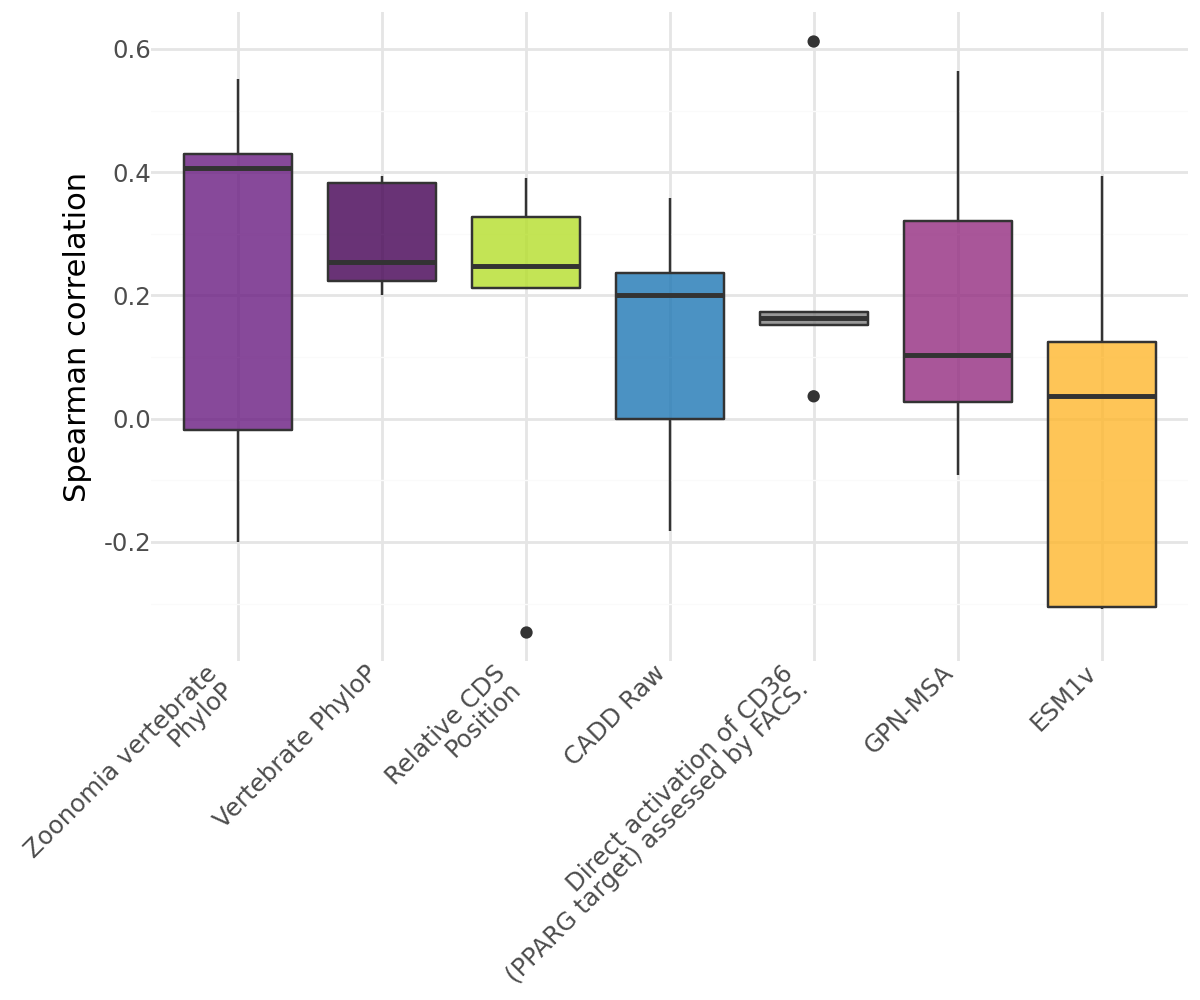

In [ ]:
med_df = pos_corr_df.drop_nans().group_by("label").agg([
    pl.col("corr_beta").median().alias("median_corr_beta"),
])

corr_pd = med_df.join(pos_corr_df, on='label').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=False)['label'].unique(),
    ordered=True
)

# Define colors
# order = corr_pd['label'].cat.categories.to_list()

color_dict = {
    # 'fitness': 'gray',
    'FoldX': 'darkorange',
    'thermoMPNN': 'orange',
    'cadd_raw': '#1f77b4', 
    'am_pathogenicity': '#e76e5b', 
    'esmscoremissense': '#feb72d', 
    'gpn_score': '#942c80', 
    'zooverphylop': '#6a1c81', 
    'verphylop': '#440154', 
    'relative_cds_position': '#b5de2b'
}

# Plot
(
    ggplot(corr_pd, aes(x='label', y='corr_beta', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_continuous(limits=[-0.5, 0.6]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [219]:
import itertools
from scipy.stats import wilcoxon

annotations = correlation_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = correlation_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = correlation_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="less")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "gene_trait_pairs", "W_stat", "pval_raw"]
).filter(pl.col("pval_raw") < 0.05)

stats_df

/tmp/ipykernel_44226/2763475614.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""esmscoremissense""","""gpn_score""",5,0.0,0.03125
"""esmscoremissense""","""zooverphylop""",5,0.0,0.03125
"""esmscoremissense""","""Direct activation of CD36 (PPA…",5,0.0,0.03125


In [197]:
stats_df.filter(pl.col('VSM_A') == 'Indirect yeast complementation assay.').sort('pval_raw')

VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""Indirect yeast complementation…","""cadd_raw""",5,0.0,0.03125


In [198]:
stats_df.filter(pl.col('VSM_B') == 'Indirect yeast complementation assay.').sort('pval_raw')

VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""relative_cds_position""","""Indirect yeast complementation…",5,0.0,0.03125
"""verphylop""","""Indirect yeast complementation…",5,0.0,0.03125


### DMS data exp.

In [ ]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    (pl.col('phenotype').is_in(appv['phenotype'].unique()))
)

a
exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet").filter(
# exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250822_Livesey_Marsh_36DMS.parquet").filter(
    pl.col('region').is_in(a['gene_id'].unique())
).drop_nulls()
exp_df['gene_name'].value_counts(sort=True)
# exp_df[['gene_name', 'gene_id', 'fitness_assay']].unique()
exp_df[['gene_name', 'gene_id', 'file_name']].unique()
exp_df.filter(pl.col('fitness_assay').str.contains('Direct protein abundance'))[0, 'fitness_assay']

## Bootstrap

In [126]:
region = correlation_df['region'].unique()[0]
phenotype = correlation_df['phenotype'].unique()[0]

gpa_df = pheno_anno.filter(
    (pl.col('region') == region) & 
    (pl.col('phenotype') == phenotype)
)
gpa_df

id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank
str,str,u32,f32,str,str,str,f32,str,str,str,f64,u32,u32
"""chr6:160136245:C:G""","""lipoprotein_a_int""",1,-0.267241,"""L289V""","""ENSG00000175003""","""cadd_raw""",3.2792,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,3,9
"""chr6:160136245:C:G""","""lipoprotein_a_int""",1,-0.267241,"""L289V""","""ENSG00000175003""","""am_pathogenicity""",0.5646,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,3,13
"""chr6:160136245:C:G""","""lipoprotein_a_int""",1,-0.267241,"""L289V""","""ENSG00000175003""","""esmscoremissense""",-11.867,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,3,2
"""chr6:160136245:C:G""","""lipoprotein_a_int""",1,-0.267241,"""L289V""","""ENSG00000175003""","""gpn_score""",-7.11,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,3,3
"""chr6:160136245:C:G""","""lipoprotein_a_int""",1,-0.267241,"""L289V""","""ENSG00000175003""","""verphylop""",1.696,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,3,8
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr6:160122201:G:A""","""lipoprotein_a_int""",31,0.240443,"""R89K""","""ENSG00000175003""","""zooverphylop""",0.539,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,7,5
"""chr6:160122201:G:A""","""lipoprotein_a_int""",31,0.240443,"""R89K""","""ENSG00000175003""","""relative_cds_position""",0.16,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,7,5
"""chr6:160122201:G:A""","""lipoprotein_a_int""",31,0.240443,"""R89K""","""ENSG00000175003""","""relprotpos""",0.161,"""ENSG00000175003""","""SLC22A1""","""continuous""",0.0328699,7,5


In [127]:
n_bootstraps = 1000

# Variant bootstrapping - resample variants instead of individuals
unique_variants = gpa_df.select('id').unique().to_series().to_list()
n_variants = len(unique_variants)

# Prepare all bootstrap variant samples
sampled_variants = np.random.choice(unique_variants, size=(n_bootstraps, n_variants), replace=True)

# Flatten and make DataFrame with bootstrap_id
boot_id_col = np.repeat(np.arange(n_bootstraps), n_variants)
sampled_flat = pl.LazyFrame({
    'bootstrap_id': boot_id_col,
    'id': sampled_variants.ravel()
})

# Lazy join to replicate rows
boot_df = sampled_flat.join(gpa_df.lazy(), on='id', how='left')
# boot_df.head().collect()

boot_corr_lazy = (
    boot_df
    .group_by(['bootstrap_id', 'annotation', 'phenotype', 'region'])
    .agg(pl.corr('mean_pheno_value_rank', 'annotation_score_rank').alias('corr'))
    .with_columns(pl.col('corr').abs().alias('abs_corr'))
    .filter(pl.col('abs_corr').is_not_null())
)

boot_corr = boot_corr_lazy.collect()
boot_corr

bootstrap_id,annotation,phenotype,region,corr,abs_corr
i64,str,str,str,f64,f64
105,"""S22A1_HUMAN_Yee_2023_activity""","""lipoprotein_a_int""","""ENSG00000175003""",-0.392975,0.392975
197,"""am_pathogenicity""","""lipoprotein_a_int""","""ENSG00000175003""",-0.325294,0.325294
319,"""esmscoremissense""","""lipoprotein_a_int""","""ENSG00000175003""",-0.129045,0.129045
821,"""am_pathogenicity""","""lipoprotein_a_int""","""ENSG00000175003""",-0.114194,0.114194
576,"""gpn_score""","""lipoprotein_a_int""","""ENSG00000175003""",-0.213866,0.213866
…,…,…,…,…,…
8,"""relprotpos""","""lipoprotein_a_int""","""ENSG00000175003""",-0.045638,0.045638
132,"""am_pathogenicity""","""lipoprotein_a_int""","""ENSG00000175003""",-0.558777,0.558777
493,"""relprotpos""","""lipoprotein_a_int""","""ENSG00000175003""",0.050873,0.050873


In [128]:
confidence_level = 0.95
alpha = 1 - confidence_level
lower_percentile = (alpha / 2) * 100
upper_percentile = (1 - alpha / 2) * 100

boot_stats_lazy = (
    boot_corr_lazy
    .group_by(['annotation', 'phenotype', 'region'])
    .agg([
        pl.col('abs_corr').mean().alias('mean_abs_corr'),
        pl.col('abs_corr').std().alias('se_abs_corr'),
        pl.col('abs_corr').quantile(lower_percentile / 100).alias('abs_corr_ci_lower'),
        pl.col('abs_corr').quantile(upper_percentile / 100).alias('abs_corr_ci_upper'),
        pl.len().alias('n_bootstraps')
    ])
    .sort('mean_abs_corr', descending=True)
)

boot_stats = boot_stats_lazy.collect()
boot_stats

annotation,phenotype,region,mean_abs_corr,se_abs_corr,abs_corr_ci_lower,abs_corr_ci_upper,n_bootstraps
str,str,str,f64,f64,f64,f64,u32
"""gpn_score""","""lipoprotein_a_int""","""ENSG00000175003""",0.337238,0.200561,0.021216,0.728968,1000
"""verphylop""","""lipoprotein_a_int""","""ENSG00000175003""",0.305743,0.211318,0.014797,0.794096,1000
"""S22A1_HUMAN_Yee_2023_activity""","""lipoprotein_a_int""","""ENSG00000175003""",0.265665,0.192267,0.012292,0.72487,1000
"""S22A1_HUMAN_Yee_2023_abundance""","""lipoprotein_a_int""","""ENSG00000175003""",0.255818,0.183314,0.01012,0.673431,1000
"""zooverphylop""","""lipoprotein_a_int""","""ENSG00000175003""",0.246928,0.190983,0.009557,0.736821,1000
"""cadd_raw""","""lipoprotein_a_int""","""ENSG00000175003""",0.242524,0.191354,0.01177,0.723703,1000
"""relative_cds_position""","""lipoprotein_a_int""","""ENSG00000175003""",0.233849,0.165454,0.011442,0.611389,1000
"""relprotpos""","""lipoprotein_a_int""","""ENSG00000175003""",0.22628,0.165872,0.011428,0.610267,1000
"""esmscoremissense""","""lipoprotein_a_int""","""ENSG00000175003""",0.221763,0.177143,0.008335,0.66983,1000


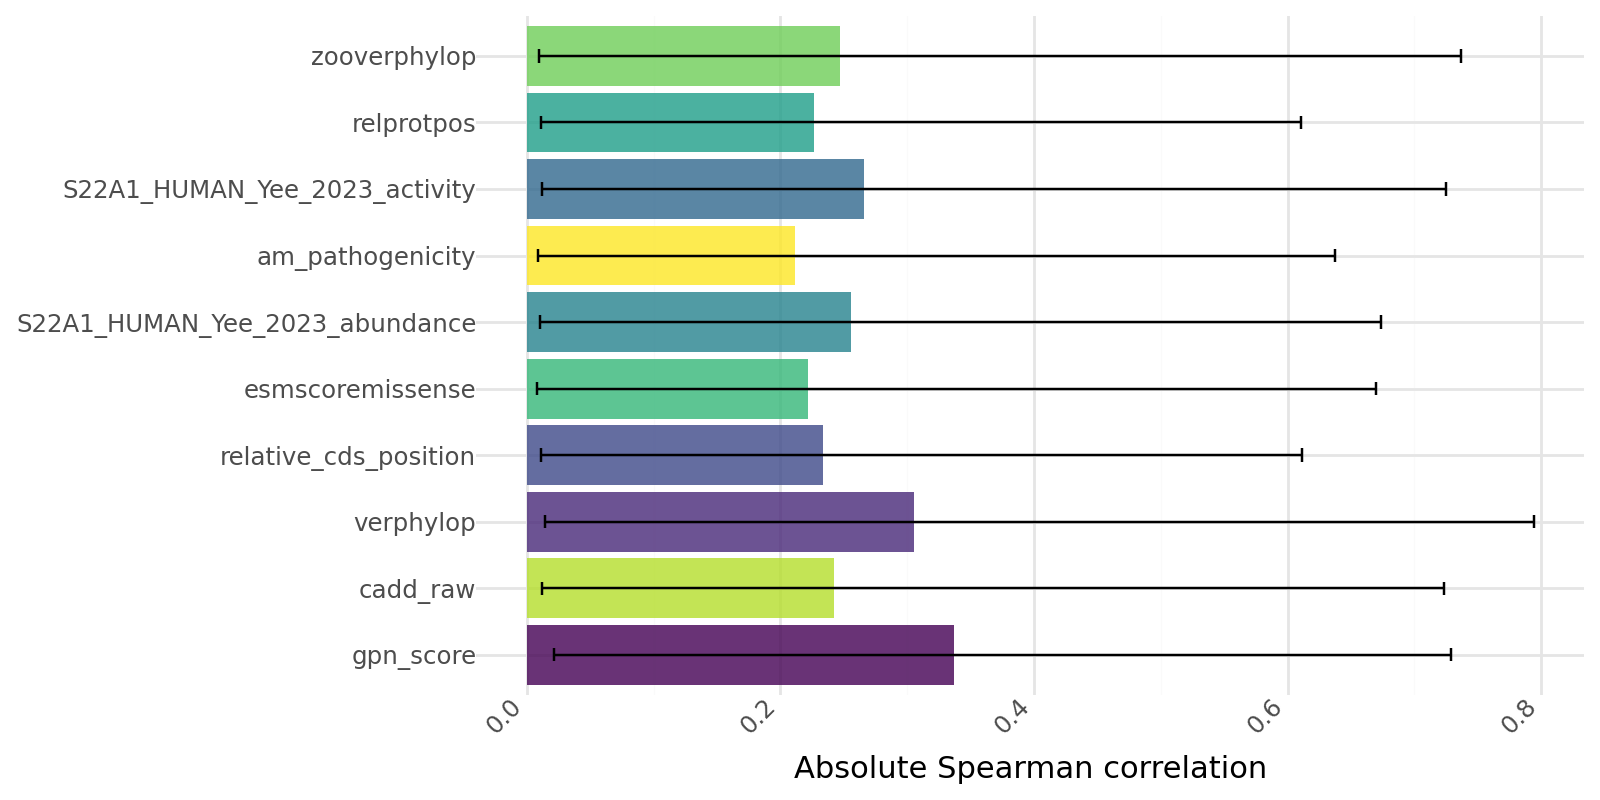

In [129]:

order = boot_stats.sort("mean_abs_corr", descending=True)["annotation"].unique().to_list()

# Plot
(
    ggplot(boot_stats, aes(x='annotation', y='mean_abs_corr', fill='annotation')) +
    geom_col(alpha=0.8) +
    geom_errorbar(aes(ymin='abs_corr_ci_lower', ymax='abs_corr_ci_upper'), width=0.2, color='black') +
    theme_minimal() +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    coord_flip() +
    theme(
        figure_size=(8, 4),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

### Anno against anno plot

In [38]:
anno1 = 'am_pathogenicity'
anno2 = 'cadd_raw'
anno1 = 'HXK4_HUMAN_Gersing_2022_activity'
anno2 = 'HXK4_HUMAN_Gersing_2023_abundance'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == 'glycated_haemoglobin_hba1c_int') &
    (pl.col('annotation').is_in([anno1, anno2]))
    # (pl.col('annotation').str.contains('HXK4'))
).pivot(
    index = ['id', 'mean_pheno_value', 'mean_pheno_value_rank'],
    on='annotation',
    values='annotation_score'
)

(
    ggplot(sc_df, aes(x=anno1, y=anno2)) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=anno1, #"DMS activity",
        y=anno2 #"DMS abundance"
    ) +
    annotate(
        "text", 
        x=3.5, y=0.1,
        label=f"Spearman r = {sc_df.select(pl.corr(anno1, anno2, method='spearman')).item():.2f}",
        size=10, color='black'
    ) +
    theme(figure_size=(5, 4))
)

ColumnNotFoundError: HXK4_HUMAN_Gersing_2022_activity

### Facet by n_variant bins

In [ ]:
n_cuts = 5
corr_pd['n_var_quantile'] = pd.qcut(corr_pd['n_variants'], n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)])
corr_pd['n_var_quantile'].value_counts()

n_var_quantile
1    289
4    187
3    170
5    153
2    119
Name: count, dtype: int64

/tmp/ipykernel_1043668/740667702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


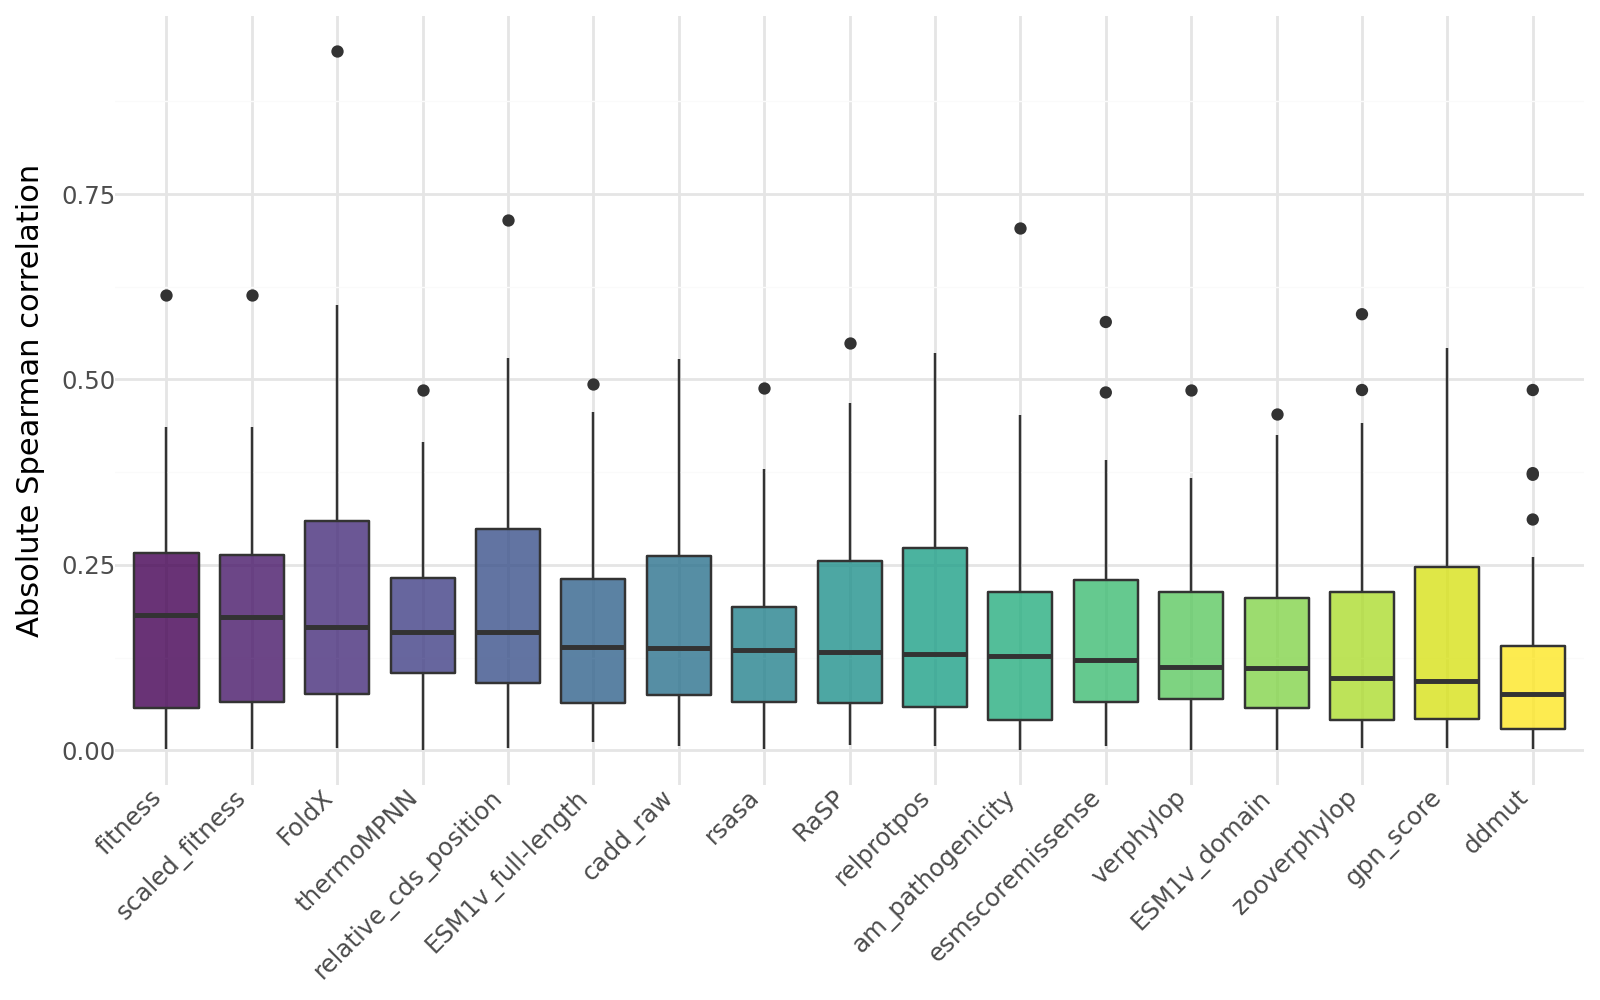

In [ ]:
corr_q1 = corr_pd[corr_pd[f'n_var_quantile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(8)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Single gene-trait association plot

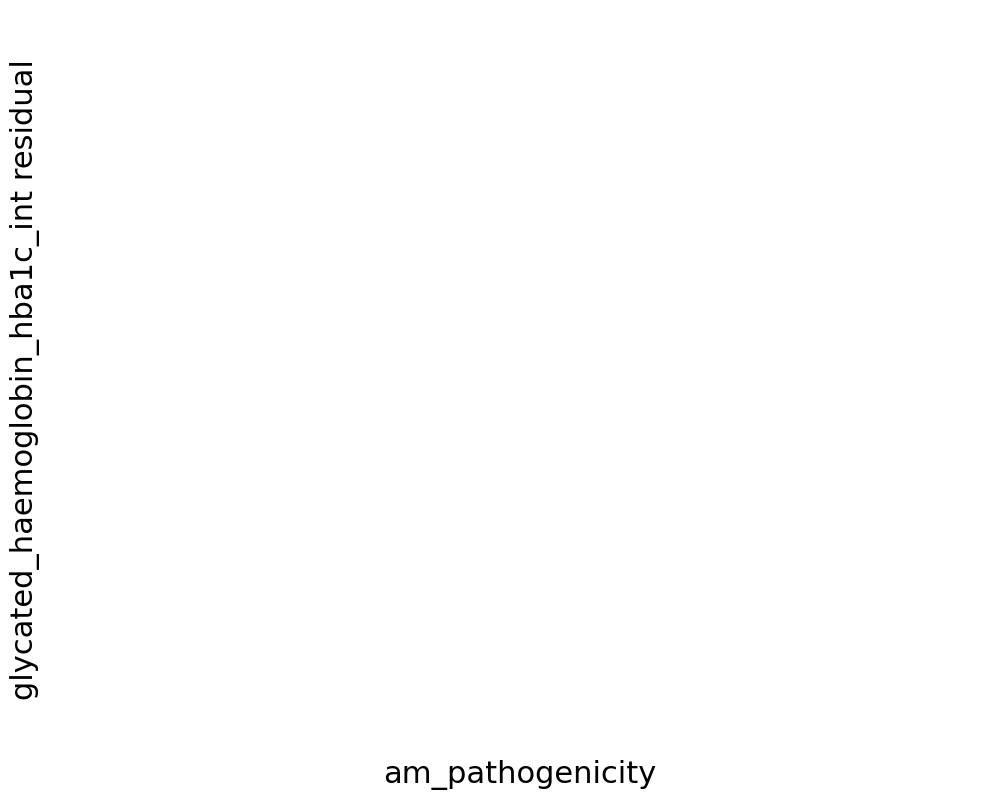

In [ ]:
method = 'pearson'
annotation = 'am_pathogenicity'
gene_name = 'GCK'
phenotype = 'glycated_haemoglobin_hba1c_int'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)

## Facet by LOEUF

In [ ]:
gene_property = 'lof.oe_ci.upper'
# gene_property = 'cds_length'

n_cuts = 10
gn = pl.read_csv(
    '/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv', 
    null_values='NA',
    separator='\t'
).filter(
    (pl.col('mane_select') == True) &
    (pl.col('transcript_type') == 'protein_coding')
).with_columns(
    pl.col(gene_property).qcut(n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)]).alias(f'{gene_property}_decile')
).to_pandas()

gn

,gene,gene_id,transcript,canonical,mane_select,lof_hc_lc.obs,lof_hc_lc.exp,lof_hc_lc.possible,lof_hc_lc.oe,lof_hc_lc.mu,...,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,level,transcript_type,chromosome,cds_length,num_coding_exons,lof.oe_ci.upper_decile
0,A1BG,ENSG00000121410,ENST00000263100,True,True,45.0,43.0480,193.0,1.04540,7.063300e-07,...,1.172,-1.166000,-0.635490,[],2,protein_coding,chr19,1485,8,8
1,A1CF,ENSG00000148584,ENST00000373997,True,True,45.0,69.9620,352.0,0.64320,9.547100e-07,...,1.103,0.032727,0.017838,[],2,protein_coding,chr10,1758,11,4
2,A2M,ENSG00000175899,ENST00000318602,True,True,95.0,147.2400,745.0,0.64522,1.344500e-06,...,0.929,3.368800,1.836200,[],2,protein_coding,chr12,4422,36,4
3,A2ML1,ENSG00000166535,ENST00000299698,True,True,146.0,176.0500,881.0,0.82930,1.700700e-06,...,0.996,1.745200,0.951210,[],2,protein_coding,chr12,4362,35,5
4,A3GALT2,ENSG00000184389,ENST00000442999,True,True,41.0,26.5590,110.0,1.54380,3.376300e-07,...,1.753,-7.333400,-3.997000,"[""outlier_mis""]",2,protein_coding,chr1,1020,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17476,None,ENSG00000284024,ENST00000640019,True,True,23.0,33.3410,150.0,0.68984,9.153200e-07,...,1.075,0.716050,0.390280,[],2,protein_coding,chr10,1083,2,7
17477,None,ENSG00000285043,ENST00000338110,True,True,9.0,19.2800,89.0,0.46680,1.504500e-07,...,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",2,protein_coding,chr16,417,4,NaN
17478,None,ENSG00000286135,ENST00000652090,True,True,0.0,1.4471,8.0,0.00000,2.520600e-08,...,1.067,1.581300,0.861890,[],2,protein_coding,chr10,411,4,9
17479,None,ENSG00000286190,ENST00000568641,True,True,4.0,3.2926,20.0,1.21480,4.915500e-08,...,1.570,-2.406500,-1.311700,[],2,protein_coding,chr17,357,1,10


In [ ]:
corr_lf = corr_pd.merge(
    gn[['gene_id', gene_property, f'{gene_property}_decile']], 
    left_on='region', 
    right_on='gene_id', 
    how='left'
)

corr_lf = corr_lf.dropna()
corr_lf

,annotation,median_abs_corr,region,gene_name,phenotype,n_variants,correlation,abs_corr,gene_id,lof.oe_ci.upper,lof.oe_ci.upper_decile
0,ESM1v_domain,0.111547,ENSG00000136068,FLNB,gamma_glutamyltransferase_int,102,0.031580,0.031580,ENSG00000136068,0.504,2
1,am_pathogenicity,0.126870,ENSG00000181722,ZBTB20,alkaline_phosphatase_int,20,-0.009023,0.009023,ENSG00000181722,0.300,1
2,fitness,0.182845,ENSG00000029534,ANK1,mean_sphered_cell_volume_int,29,-0.155172,0.155172,ENSG00000029534,0.299,1
3,relative_cds_position,0.159919,ENSG00000101191,DIDO1,leg_fat_percentage_left_int,16,0.400000,0.400000,ENSG00000101191,0.235,1
4,relative_cds_position,0.159919,ENSG00000165702,GFI1B,platelet_distribution_width_int,16,-0.270588,0.270588,ENSG00000165702,0.761,4
...,...,...,...,...,...,...,...,...,...,...,...
913,zooverphylop,0.097122,ENSG00000101191,DIDO1,body_mass_index_bmi_int,16,0.179412,0.179412,ENSG00000101191,0.235,1
914,fitness,0.182845,ENSG00000136068,FLNB,mean_platelet_thrombocyte_volume_int,105,0.139747,0.139747,ENSG00000136068,0.504,2
915,ESM1v_domain,0.111547,ENSG00000163867,ZMYM6,sitting_height_int,19,0.085965,0.085965,ENSG00000163867,0.773,4
916,am_pathogenicity,0.126870,ENSG00000111249,CUX2,platelet_crit_int,49,-0.128776,0.128776,ENSG00000111249,0.383,1


In [ ]:
corr_lf[['region', 'phenotype', f'{gene_property}_decile']].drop_duplicates()[f'{gene_property}_decile'].value_counts(sort=True)

lof.oe_ci.upper_decile
1     22
3     11
4     10
2      9
10     2
5      0
6      0
7      0
8      0
9      0
Name: count, dtype: int64

/tmp/ipykernel_1043668/1970709719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 3 rows containing non-finite values.


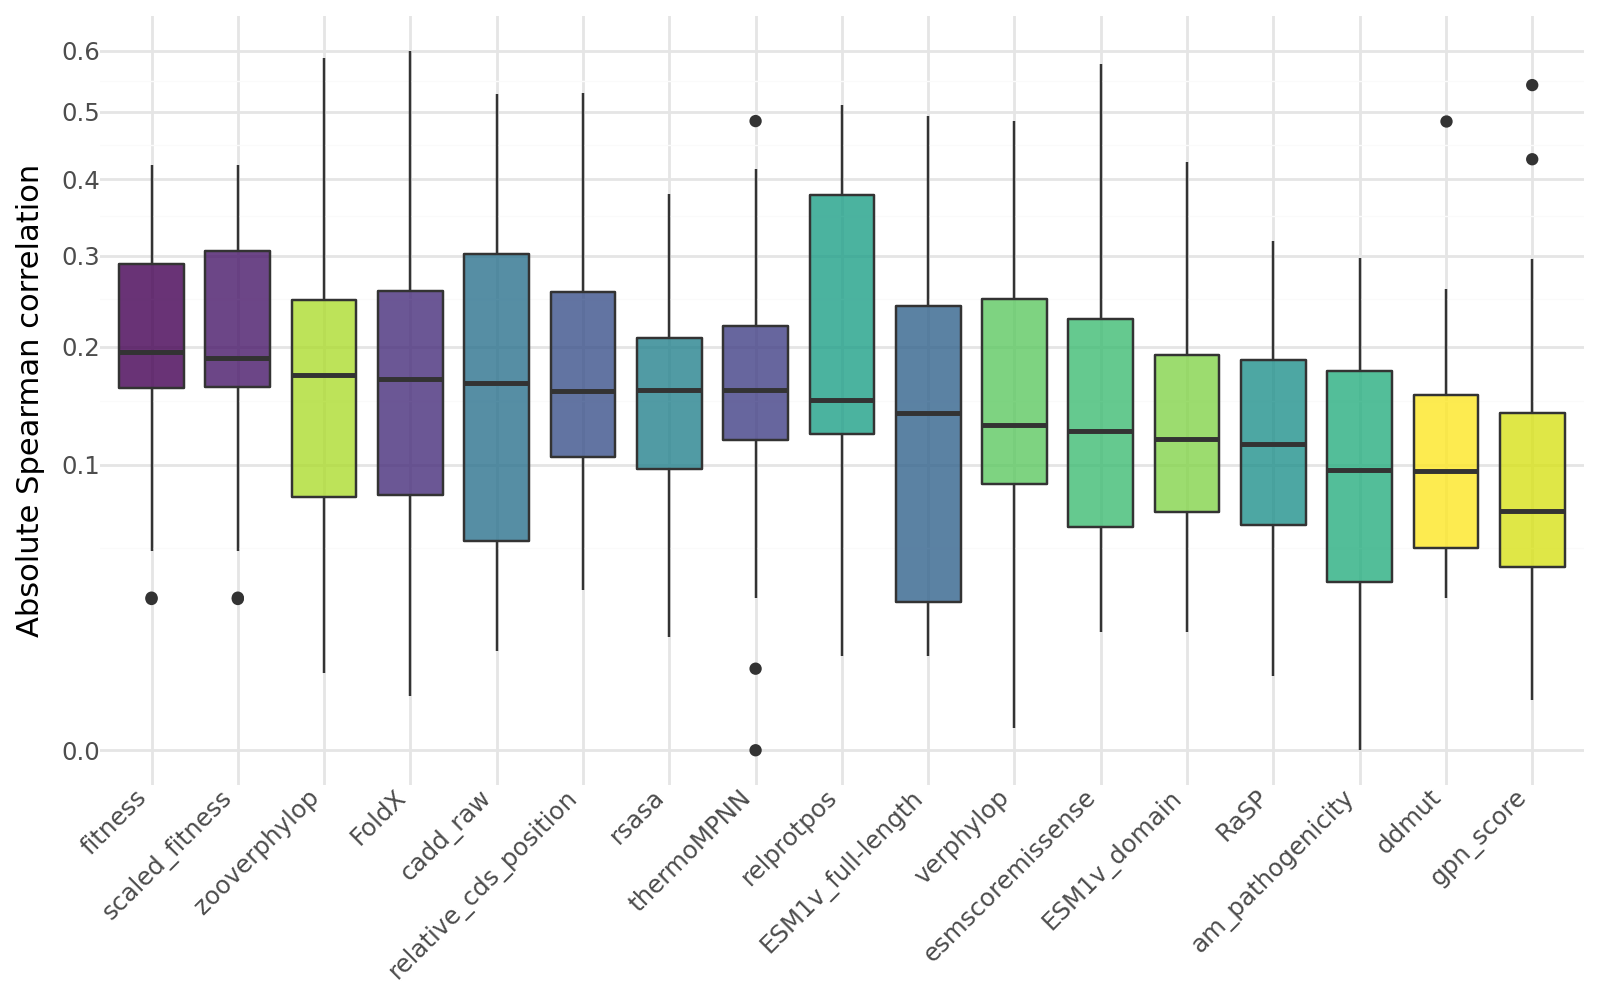

In [ ]:
corr_q1 = corr_lf[corr_lf[f'{gene_property}_decile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q1, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

/tmp/ipykernel_1043668/1725476563.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


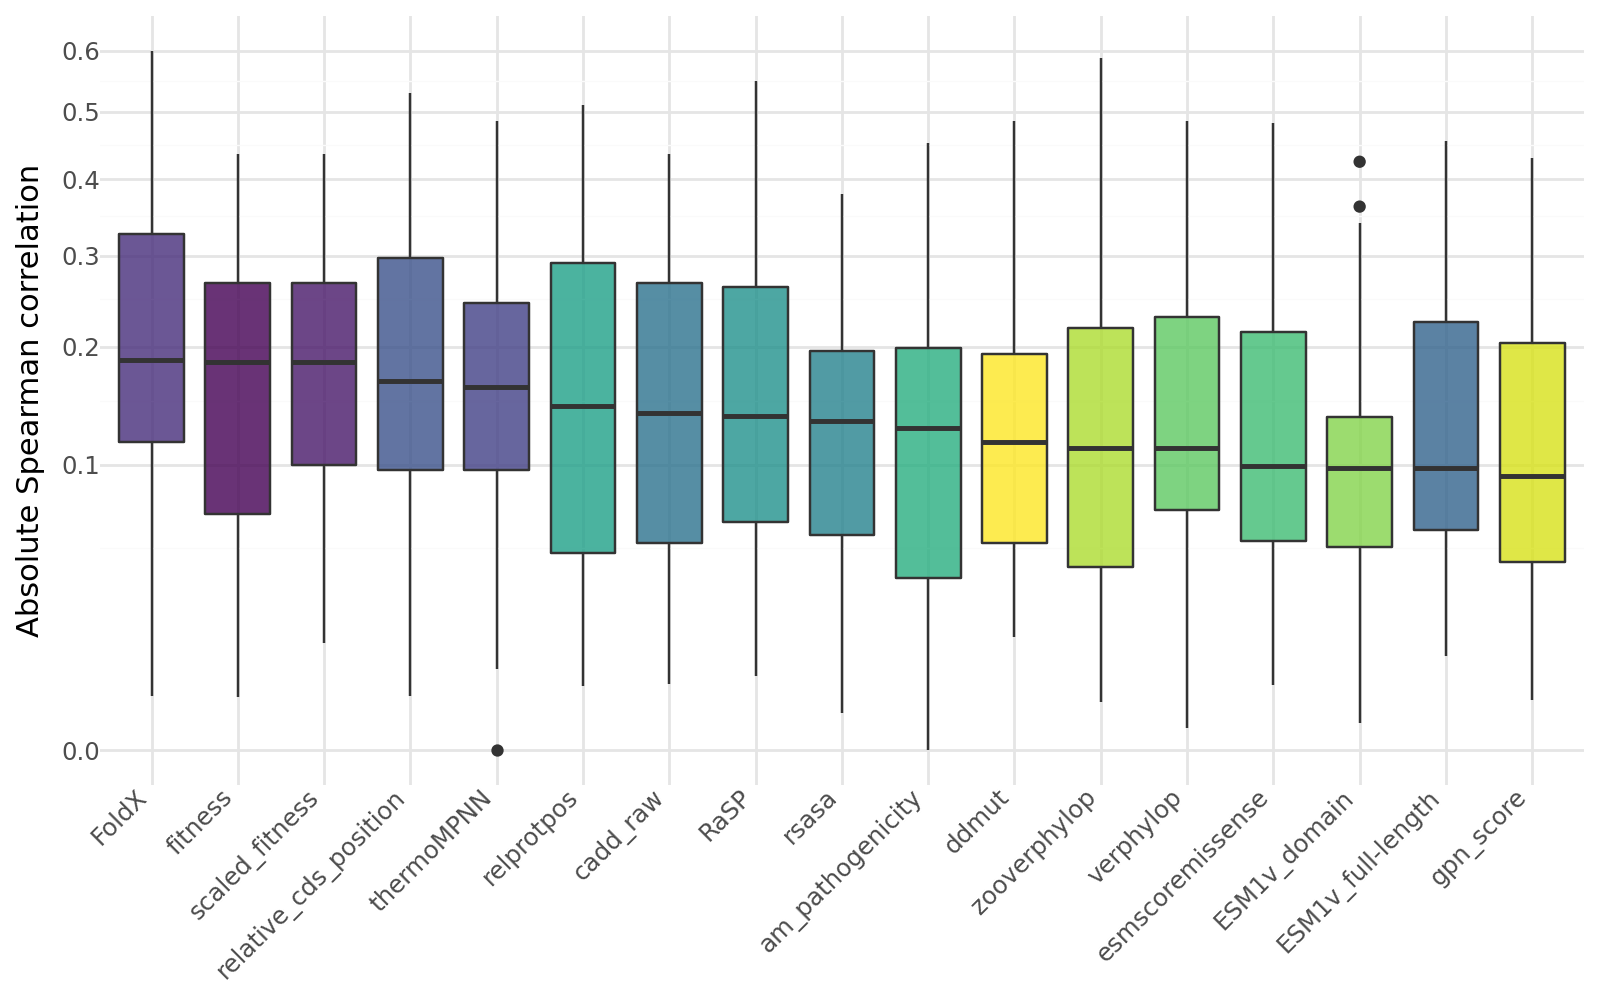

In [ ]:
corr_q10 = corr_lf[corr_lf[f'{gene_property}_decile']=='10']

med_df = (
    corr_q10
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q10 = corr_q10.merge(med_df, on='annotation')
order = corr_q10.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q10, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Enrichment of true extremes in predicted extremes

In [ ]:
gene_trait_df = gene_trait_df.with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)
gene_trait_df

region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000101191""","""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""continuous""",0.738026,1.0
"""ENSG00000124507""","""ENSG00000124507""","""PACSIN1""","""hip_circumference_int""","""continuous""",0.026021,1.0
"""ENSG00000124507""","""ENSG00000124507""","""PACSIN1""","""weight_int""","""continuous""",-0.029657,-1.0
"""ENSG00000170004""","""ENSG00000170004""","""CHD3""","""testosterone_int""","""continuous""",0.0822522,1.0
"""ENSG00000163554""","""ENSG00000163554""","""SPTA1""","""glycated_haemoglobin_hba1c_int""","""continuous""",-0.668832,-1.0
…,…,…,…,…,…,…
"""ENSG00000136068""","""ENSG00000136068""","""FLNB""","""mean_platelet_thrombocyte_volu…","""continuous""",0.0597711,1.0
"""ENSG00000165702""","""ENSG00000165702""","""GFI1B""","""mean_platelet_thrombocyte_volu…","""continuous""",0.426949,1.0
"""ENSG00000103449""","""ENSG00000103449""","""SALL1""","""haematocrit_percentage_int""","""continuous""",0.0554231,1.0


In [ ]:
pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
pos_assoc

region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000101191""","""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""continuous""",0.738026,1.0
"""ENSG00000124507""","""ENSG00000124507""","""PACSIN1""","""hip_circumference_int""","""continuous""",0.026021,1.0
"""ENSG00000170004""","""ENSG00000170004""","""CHD3""","""testosterone_int""","""continuous""",0.0822522,1.0
"""ENSG00000165702""","""ENSG00000165702""","""GFI1B""","""eosinophill_percentage_int""","""continuous""",0.353109,1.0
"""ENSG00000163867""","""ENSG00000163867""","""ZMYM6""","""whole_body_water_mass_int""","""continuous""",0.0334119,1.0
…,…,…,…,…,…,…
"""ENSG00000136068""","""ENSG00000136068""","""FLNB""","""mean_platelet_thrombocyte_volu…","""continuous""",0.0597711,1.0
"""ENSG00000165702""","""ENSG00000165702""","""GFI1B""","""mean_platelet_thrombocyte_volu…","""continuous""",0.426949,1.0
"""ENSG00000103449""","""ENSG00000103449""","""SALL1""","""haematocrit_percentage_int""","""continuous""",0.0554231,1.0


In [ ]:
ct_df = pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
)

xtm_df = pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")

# Restrict to postive associations
# pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
# xtm_df = xtm_df.join(pos_assoc[['region', 'phenotype']], on=['region', 'phenotype'], how='inner')
xtm_df = xtm_df.join(gene_trait_df[['region', 'phenotype', 'beta_dir']], on=['region', 'phenotype'], how='inner')

xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_same_dir"),
    (pl.col("annotation_score_rank") / pl.col("n_variants")).alias("annotation_score_ptile")
)

gpn_df = xtm_df.filter(pl.col('annotation')=='gpn_score').with_columns(
    (1-pl.col('annotation_score_ptile')).alias('annotation_score_ptile'),
    pl.lit('gpn_score_rev').alias('annotation')
)

xtm_df = pl.concat([xtm_df, gpn_df])
xtm_df

id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank,n_variants,beta_dir,mean_pheno_value_same_dir,annotation_score_ptile
str,str,u32,f32,str,str,str,f32,str,str,str,f64,u32,u32,u32,f64,f64,f64
"""chr17:7894525:A:G""","""testosterone_int""",1,-0.279244,"""T396A""","""ENSG00000170004""","""cadd_raw""",4.093093,"""ENSG00000170004""","""CHD3""","""continuous""",0.0822522,3,2,13,1.0,-0.279244,0.153846
"""chr17:7894525:A:G""","""testosterone_int""",1,-0.279244,"""T396A""","""ENSG00000170004""","""am_pathogenicity""",0.6999,"""ENSG00000170004""","""CHD3""","""continuous""",0.0822522,3,4,13,1.0,-0.279244,0.307692
"""chr17:7894525:A:G""","""testosterone_int""",1,-0.279244,"""T396A""","""ENSG00000170004""","""esmscoremissense""",-4.314,"""ENSG00000170004""","""CHD3""","""continuous""",0.0822522,3,9,13,1.0,-0.279244,0.692308
"""chr17:7894525:A:G""","""testosterone_int""",1,-0.279244,"""T396A""","""ENSG00000170004""","""gpn_score""",-11.22,"""ENSG00000170004""","""CHD3""","""continuous""",0.0822522,3,8,13,1.0,-0.279244,0.615385
"""chr17:7894525:A:G""","""testosterone_int""",1,-0.279244,"""T396A""","""ENSG00000170004""","""verphylop""",6.701,"""ENSG00000170004""","""CHD3""","""continuous""",0.0822522,3,5,13,1.0,-0.279244,0.384615
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:158653423:G:C""","""mean_corpuscular_haemoglobin_c…",17,0.025021,"""D1013E""","""ENSG00000163554""","""gpn_score_rev""",-7.77,"""ENSG00000163554""","""SPTA1""","""continuous""",0.499937,12,5,22,1.0,0.025021,0.772727
"""chr1:158653425:C:A""","""mean_corpuscular_haemoglobin_c…",1,0.46567,"""D1013Y""","""ENSG00000163554""","""gpn_score_rev""",-9.78,"""ENSG00000163554""","""SPTA1""","""continuous""",0.499937,19,2,22,1.0,0.46567,0.909091
"""chr1:158654615:T:C""","""mean_corpuscular_haemoglobin_c…",29,-0.014974,"""N1011S""","""ENSG00000163554""","""gpn_score_rev""",-2.93,"""ENSG00000163554""","""SPTA1""","""continuous""",0.499937,10,17,22,1.0,-0.014974,0.227273


In [ ]:
pred_cutoff = 0.1
xtm_df = xtm_df.with_columns(
        (pl.col("annotation_score_ptile") <= pred_cutoff).alias("low_predicted"),
        (pl.col("annotation_score_ptile") >= 1 - pred_cutoff).alias("high_predicted"),
)

enr_df_list = []
for z_alpha in tqdm(range(200)):
    z_score = z_alpha/100
    pr_temp = xtm_df.filter(
        (pl.col("mean_pheno_value") >= z_score)
    ).group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        (pl.count().alias("high_true")),
        (pl.col("high_predicted").sum()).alias("high_correct"),
        
    ).with_columns(
        (pl.col("high_correct") / pl.col("high_true")).alias("high_enrichment"),
        pl.lit(z_score).alias('z_score')
    )

    enr_df_list.append(pr_temp)

enr_df = pl.concat(enr_df_list)
enr_df

  0%|          | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_760855/2519579336.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
100%|██████████| 200/200 [00:00<00:00, 432.86it/s]


annotation,region,phenotype,high_true,high_correct,high_enrichment,z_score
str,str,str,u32,u32,f64,f64
"""zooverphylop""","""ENSG00000124507""","""hip_circumference_int""",13,1,0.076923,0.0
"""ddmut""","""ENSG00000111249""","""platelet_crit_int""",21,4,0.190476,0.0
"""scaled_fitness""","""ENSG00000101191""","""arm_fat_mass_left_int""",6,1,0.166667,0.0
"""ESM1v_full-length""","""ENSG00000163554""","""mean_corpuscular_haemoglobin_i…",12,1,0.083333,0.0
"""rsasa""","""ENSG00000165702""","""mean_platelet_thrombocyte_volu…",10,2,0.2,0.0
…,…,…,…,…,…,…
"""RaSP""","""ENSG00000165702""","""mean_platelet_thrombocyte_volu…",1,0,0.0,1.99
"""ddmut""","""ENSG00000029534""","""reticulocyte_count_int""",1,0,0.0,1.99
"""am_pathogenicity""","""ENSG00000165702""","""mean_platelet_thrombocyte_volu…",1,0,0.0,1.99


In [ ]:
annos_to_keep = [
 'verphylop',
 'zooverphylop',
 'gpn_score',
 'gpn_score_rev',
 'relative_cds_position',
 'esmscoremissense',
 'cadd_raw',
 'am_pathogenicity',
 'fitness',
 'scaled_fitness',
 'ESM1v_domain',
 'RaSP',
 'ddmut',
 'FoldX',
 'rsasa',
 'thermoMPNN',
 'ESM1v_full-length',
 ]

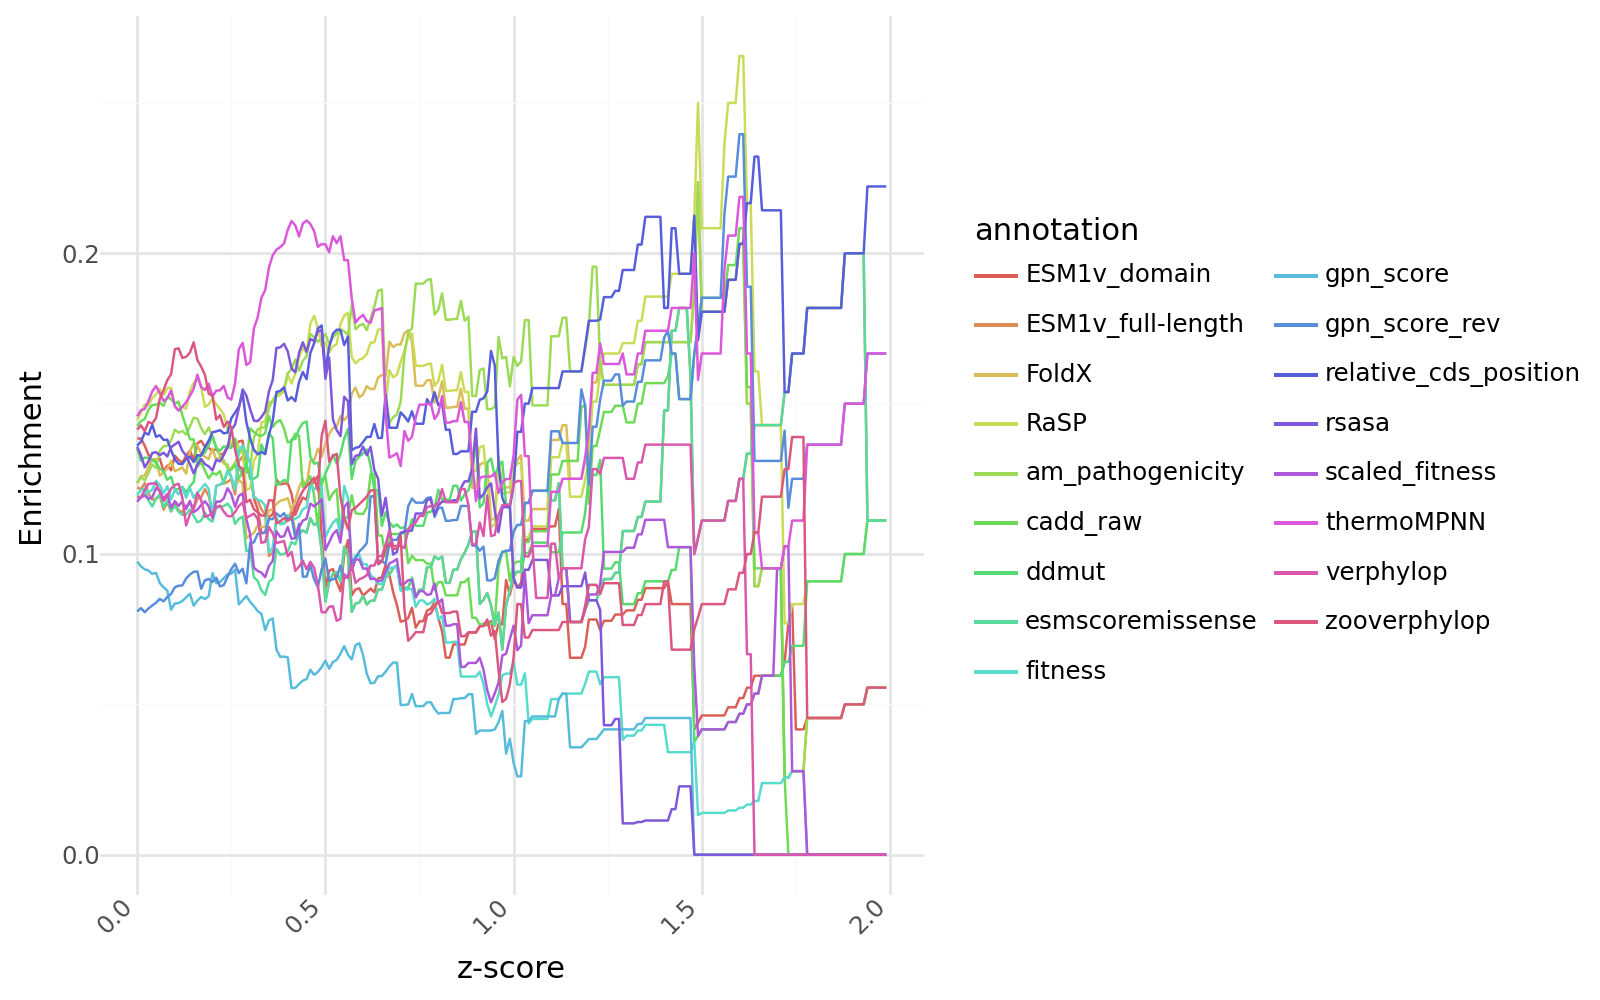

In [ ]:
plot_df = enr_df.group_by('annotation', 'z_score').agg(pl.col('high_enrichment').mean())

(
    ggplot(plot_df.filter(pl.col('annotation').is_in(annos_to_keep)), aes(x='z_score', y='high_enrichment', color='annotation')) +
    geom_line() +
    # theme_538() +
    theme_minimal() +
    # scale_color_manual(values=color_dict) +
    labs(
        x='z-score',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 5),
        # legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)